In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
raw_data_kaggle = pd.read_csv("../data/kaggle_dataset_features.csv")
raw_data_crawled = pd.read_csv("../data/crawled_dataset_features.csv")
raw_data = pd.concat([raw_data_crawled, raw_data_kaggle], axis=0)
raw_data.head(10)

,seller,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,fuelType,brand,price,price_tier
0,Dealer,suv/off-road/pick-up,2017.0,manual,82.0,122566.0,gasoline,peugeot,7450,budget
1,Dealer,suv/off-road/pick-up,2026.0,automatic,150.0,10.0,gasoline,volkswagen,30995,mid-range
2,Dealer,suv/off-road/pick-up,2020.0,automatic,98.0,77984.0,electric/gasoline,toyota,18900,mid-range
3,Dealer,station wagon,2016.0,automatic,170.0,114483.0,gasoline,subaru,15600,mid-range
4,Dealer,suv/off-road/pick-up,2023.0,manual,150.0,27682.0,gasoline,skoda,20900,mid-range
5,Dealer,suv/off-road/pick-up,2016.0,manual,150.0,79946.0,diesel,land,13500,budget
6,Dealer,sedan,2023.0,manual,95.0,29532.0,gasoline,volkswagen,15025,mid-range
7,Dealer,van,2024.0,automatic,131.0,53951.0,diesel,toyota,27490,mid-range
8,Dealer,suv/off-road/pick-up,2017.0,manual,131.0,113455.0,gasoline,peugeot,11990,budget
9,Dealer,compact,2025.0,manual,101.0,1.0,lpg,renault,19490,mid-range


In [5]:
print(f"Shape of the dataset: {raw_data.shape}")
print(raw_data.info())

Shape of the dataset: (374035, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 374035 entries, 0 to 371527
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   seller              374035 non-null  object 
 1   vehicleType         336166 non-null  object 
 2   yearOfRegistration  373966 non-null  float64
 3   gearbox             353822 non-null  object 
 4   powerPS             374028 non-null  float64
 5   kilometer           374014 non-null  float64
 6   fuelType            340647 non-null  object 
 7   brand               374035 non-null  object 
 8   price               374035 non-null  int64  
 9   price_tier          363257 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 31.4+ MB
None


In [6]:
# count categorical cols, numerical cols and date cols
categorical_cols = raw_data.select_dtypes(exclude="number").columns
numerical_cols = raw_data.select_dtypes(include="number").columns
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))
missing_values = raw_data.isnull().sum()
print("Total missing values in the dataset:", missing_values.sum())



Categorical columns: 6
Numerical columns: 4


Total missing values in the dataset: 102345


In [7]:
numerical_cols_ = raw_data[["powerPS", "yearOfRegistration", "kilometer"]]
for col in numerical_cols_:
    print(f"Summary statistics for {col}:")
    print(raw_data[col].describe())
    print("\n")

Summary statistics for powerPS:
count    374028.000000
mean        115.981935
std         191.775747
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64


Summary statistics for yearOfRegistration:
count    373966.000000
mean       2004.676607
std          92.572502
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64


Summary statistics for kilometer:
count    374014.000000
mean     125298.651171
std       40548.437927
min           0.000000
25%      100000.000000
50%      150000.000000
75%      150000.000000
max      999999.000000
Name: kilometer, dtype: float64




In [8]:
# exploring price col
print("Price column info:")
print(raw_data["price"].describe())

Price column info:
count    3.740350e+05
mean     1.736987e+04
std      3.575910e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.990000e+03
75%      7.350000e+03
max      2.147484e+09
Name: price, dtype: float64


In [9]:
categorical_cols_ = raw_data.select_dtypes(exclude="number")
for col in categorical_cols_:
    if col == "name": continue
    print(f"\nCategories values in {col}:\n{raw_data[col].value_counts()}")
    print("\npercentage of each category:")
    print((raw_data[col].value_counts() * 100 / len(raw_data)).round(2))


Categories values in seller:
seller
privat        371525
Dealer          2507
gewerblich         3
Name: count, dtype: int64

percentage of each category:
seller
privat        99.33
Dealer         0.67
gewerblich     0.00
Name: count, dtype: float64

Categories values in vehicleType:
vehicleType
limousine               95894
kleinwagen              80023
kombi                   67564
bus                     30201
cabrio                  22898
coupe                   19087
suv                     14707
andere                   3357
suv/off-road/pick-up     1083
sedan                     532
compact                   306
station wagon             246
van                       147
convertible                75
other                      46
Name: count, dtype: int64

percentage of each category:
vehicleType
limousine               25.64
kleinwagen              21.39
kombi                   18.06
bus                      8.07
cabrio                   6.12
coupe                    5.10
suv 

In [10]:
# defining the threshold for the price tiers
price_thresholds = [0, 15000, 35000, float("inf")]
print(raw_data["price_tier"].value_counts())
print((raw_data["price_tier"].value_counts()/len(raw_data["price_tier"]) * 100).round(2), "%")
# print(raw_data_no_outliers[["price", "price_tier"]].head())

price_tier
budget       329515
mid-range     29238
luxury         4504
Name: count, dtype: int64
price_tier
budget       88.10
mid-range     7.82
luxury        1.20
Name: count, dtype: float64 %


In [11]:
# checking for missing values
missing_values = raw_data.isnull().sum()

print("Total missing values in the dataset:", missing_values.sum())
print("Missing values in each column:")
print(f"{missing_values[missing_values > 0]}")
print(f"{(missing_values[missing_values > 0] * 100 / len(raw_data)).round(2)}")

Total missing values in the dataset: 102345
Missing values in each column:
vehicleType           37869
yearOfRegistration       69
gearbox               20213
powerPS                   7
kilometer                21
fuelType              33388
price_tier            10778
dtype: int64
vehicleType           10.12
yearOfRegistration     0.02
gearbox                5.40
powerPS                0.00
kilometer              0.01
fuelType               8.93
price_tier             2.88
dtype: float64


In [12]:
# checking for full-duplicates rows
duplicate_rows = raw_data[raw_data.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0])


Number of duplicate rows: 67152


In [13]:
raw_data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
371523    False
371524    False
371525    False
371526    False
371527    False
Length: 374035, dtype: bool

In [14]:
print(raw_data["yearOfRegistration"].describe())
print(raw_data["yearOfRegistration"].skew())

count    373966.000000
mean       2004.676607
std          92.572502
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64
72.34539486718856


In [15]:
print(raw_data["powerPS"].describe())

count    374028.000000
mean        115.981935
std         191.775747
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64


In [16]:
# Data Validity Checks
print("Check for invalid powerPS values (<= 0) or (>= 5000):")
print(raw_data[raw_data['powerPS']<=0]["powerPS"].count())
print(raw_data[raw_data['powerPS']>=5000]["powerPS"].count())
print(f"Total invalid powerPS values: {(raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count())}")
print(f"percentage of invalid powerPS values: {((raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid kilometer values (< 0) or (> 300000):")
print(raw_data[raw_data['kilometer']<0]["kilometer"].count())
print(raw_data[raw_data['kilometer']>300000]["kilometer"].count())
print(f"Total invalid kilometer values: {(raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count())}")
print(f"percentage of invalid kilometer values: {((raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid yearOfRegistration values (< 1900):")
print(raw_data[raw_data['yearOfRegistration']<1900]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print("Check for invalid yearOfRegistration values (> 2023):")
print(raw_data[raw_data['yearOfRegistration']>2023]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print(f"percentage of invalid yearOfRegistration values: {((raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid powerPS values (<= 0) or (>= 5000):
40820
87
Total invalid powerPS values: 40907
percentage of invalid powerPS values: 10.94% 
Check for invalid kilometer values (< 0) or (> 300000):
0
13
Total invalid kilometer values: 13
percentage of invalid kilometer values: 0.0% 
Check for invalid yearOfRegistration values (< 1900):
68
Total invalid yearOfRegistration values: 68
Check for invalid yearOfRegistration values (> 2023):
669
Total invalid yearOfRegistration values: 737
percentage of invalid yearOfRegistration values: 0.2% 


In [17]:
print("Check for invalid price values (< 0):")
print(raw_data[raw_data['price']<0]["price"].count())
print(f"Total invalid price values: {raw_data[raw_data['price']<0]['price'].count()}")
print(f"percentage of invalid price values: {((raw_data[raw_data['price']<0]['price'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid price values (< 0):
0
Total invalid price values: 0
percentage of invalid price values: 0.0% 


In [18]:
# removing outliers from price col using IQR method
print(raw_data["price"].describe())
Q1 = raw_data["price"].quantile(0.25)
Q3 = raw_data["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
raw_data_outliers = raw_data[(raw_data["price"] < lower_bound) | (raw_data["price"] > upper_bound)]
raw_data_no_outliers = raw_data[(raw_data["price"] >= lower_bound) & (raw_data["price"] <= upper_bound)]
print("Number of outliers in price column:", raw_data_outliers.shape[0])
print("Percentage of outliers in price column:", (raw_data_outliers.shape[0] / len(raw_data)) * 100)


count    3.740350e+05
mean     1.736987e+04
std      3.575910e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.990000e+03
75%      7.350000e+03
max      2.147484e+09
Name: price, dtype: float64
Number of outliers in price column: 28424
Percentage of outliers in price column: 7.599288836606199


In [19]:
# Outliers in kilometer col using IQR method
print(raw_data["kilometer"].describe())
Q1_km = raw_data["kilometer"].quantile(0.25)
Q3_km = raw_data["kilometer"].quantile(0.75)
IQR_km = Q3_km - Q1_km
lower_bound_km = Q1_km - 1.5 * IQR_km
upper_bound_km = Q3_km + 1.5 * IQR_km
raw_data_km_outliers = raw_data[(raw_data["kilometer"] < lower_bound_km) | (raw_data["kilometer"] > upper_bound_km)]
raw_data_km_no_outliers = raw_data[(raw_data["kilometer"] >= lower_bound_km) & (raw_data["kilometer"] <= upper_bound_km)]
print("Number of outliers in kilometer column:", raw_data_km_outliers.shape[0])
print("Percentage of outliers in kilometer column:", (raw_data_km_outliers.shape[0] / len(raw_data)) * 100) 

count    374014.000000
mean     125298.651171
std       40548.437927
min           0.000000
25%      100000.000000
50%      150000.000000
75%      150000.000000
max      999999.000000
Name: kilometer, dtype: float64
Number of outliers in kilometer column: 15397
Percentage of outliers in kilometer column: 4.116459689601241


In [20]:
# Skewness
print("Skewness of price column:", raw_data["price"].skew())
print("Skewness of kilometer column:", raw_data["kilometer"].skew())
print("Skewness of power column:", raw_data["powerPS"].skew())
print("Skewness of registration year column:", raw_data["yearOfRegistration"].skew())

Skewness of price column: 580.0054757394953
Skewness of kilometer column: -1.4836891928509217
Skewness of power column: 58.138856726130136
Skewness of registration year column: 72.34539486718856


In [21]:
# Checking Consistency - Schema & Data Types
print("Data Types of Each Column:")
print(raw_data.dtypes)


Data Types of Each Column:
seller                 object
vehicleType            object
yearOfRegistration    float64
gearbox                object
powerPS               float64
kilometer             float64
fuelType               object
brand                  object
price                   int64
price_tier             object
dtype: object


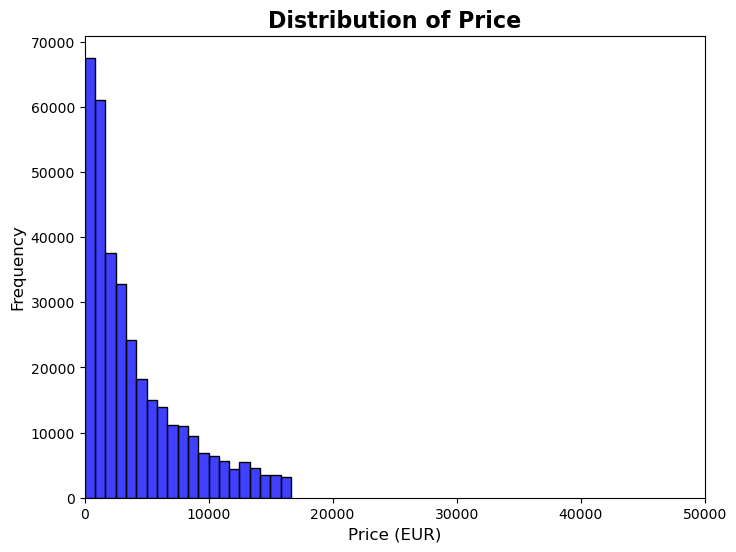

In [22]:
# visualizing the distribution of price tiers
plt.figure(figsize=(8, 6))
sns.histplot(raw_data_no_outliers["price"], bins=20, color="blue")
plt.title("Distribution of Price", fontsize=16, fontweight='bold')
plt.xlabel("Price (EUR)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 50000)
plt.savefig("../reports/price_distribution.png")
plt.show()

ValueError: cannot reindex on an axis with duplicate labels

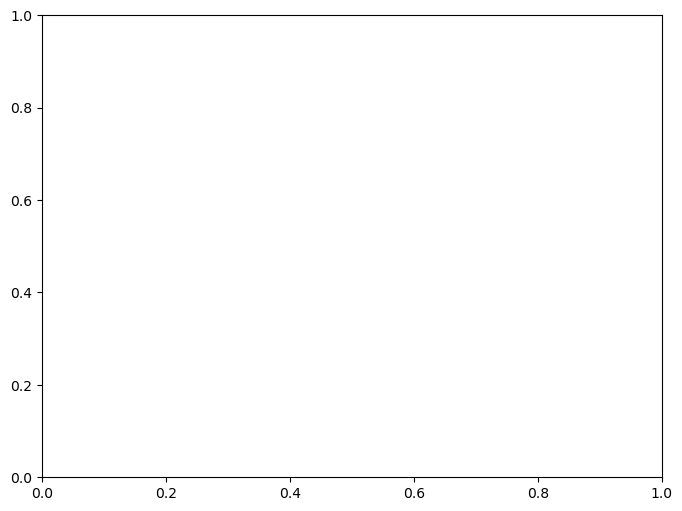

In [23]:
plt.figure(figsize=(8, 6))
sns.countplot(x="price_tier", data=raw_data)
plt.title("Distribution of Price Tiers", fontsize=16, fontweight='bold')
plt.xlabel("Price Tier", fontsize=12)
plt.ylabel("Count", fontsize=12)
for index, value in enumerate(raw_data["price_tier"].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.savefig("../reports/price_tier_distribution.png")
plt.show()

In [ ]:
raw_data.head()

,seller,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,fuelType,brand,price,price_tier
0,privat,NaN,1993,manuell,0,150000,benzin,volkswagen,480,budget
1,privat,coupe,2011,manuell,190,125000,diesel,audi,18300,mid-range
2,privat,suv,2004,automatik,163,125000,diesel,jeep,9800,budget
3,privat,kleinwagen,2001,manuell,75,150000,benzin,volkswagen,1500,budget
4,privat,kleinwagen,2008,manuell,69,90000,diesel,skoda,3600,budget
